# Kirkendall: A PFC application

In this application, Ref. [1] is reproduced.

[1]: ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.

## Free Energy

The free energy functional of the Kirkendall model reads:

\begin{align}
F = \int d\mathbf{x}\left[\frac{n}{2}\Lamba^0n - \frac{t}{3}n^3 + \right]
\end{align}

## Implementation 

### Laplacian Operator 

In [1]'s dynamical Eqn. (3~4), there are Laplacian operations again and again, in order to simplify the code and to increase the accuracy of the Laplacian operator, the `scipy.ndimage.laplace` function in the scipy package is used.

The following code is used to compare our function in the [PFC: Grain Boundary Evolution](./pfc-gb.ipynb) section, and in this section:

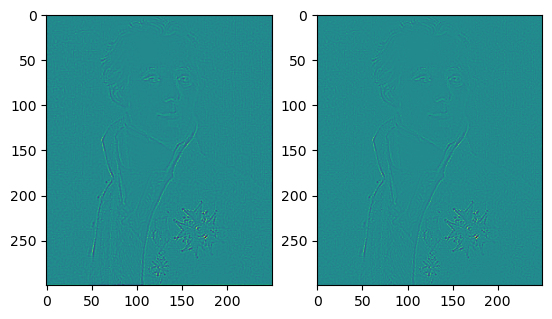

In [19]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
def laplacian(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    phi_ipjp = np.roll(phi, (1,1), axis=(0,1))
    phi_ipjm = np.roll(phi, (1,-1), axis=(0,1))
    phi_imjp = np.roll(phi, (-1,1), axis=(0,1))
    phi_imjm = np.roll(phi, (-1,-1), axis=(0,1))
    phi_lap = (0.5*(phi_ipj0+phi_imj0+phi_i0jp+phi_i0jm)+0.25*(phi_ipjp+phi_imjp+phi_ipjm+phi_imjm)-3*phi)/(dx**2.0)
    return(phi_lap)
def lap(phi, dx):
    v = ndimage.laplace(phi)/(dx**2)
    return(v)

img = plt.imread('../images/Laplace-Pierre-Simon.jpg')
img_gray = img.mean(axis=2)
edge1 = laplacian(img_gray, 0.1)
edge2 = lap(img_gray, 0.1)
fig = plt.figure()
ax1 = fig.add_subplot(121)  # left side
ax2 = fig.add_subplot(122)  # right side
ax1.imshow(edge1)
ax2.imshow(edge2)

## the Kirkendall Dynamics

In Ref. [1]'s Eq. (3~4):

\begin{align}
\frac{\partial n_A}{\partial t} &= M_A\nabla^2\left\{\Lambda^0n-tn^2+vn^3+\left[w+B_2^ln^2\right]\psi+u\psi^3-K\nabla^2\psi\right\} \\
\frac{\partial n_B}{\partial t} &= M_B\nabla^2\left\{\Lambda^0n-tn^2+vn^3-\left[w+B_2^ln^2\right]\psi-u\psi^3+K\nabla^2\psi\right\} 
\end{align}

since $n=n_A+n_B$ and $\psi=n_A-n_B$:

\begin{align}
\frac{\partial n}{\partial t} &= (M_A+M_B)\nabla^2\left(\Lambda^0n-tn^2+vn^3\right) \nonumber  \\
&+ (M_A-M_B)\left[\left(w+B_2^ln^2\right)\psi+u\psi^3-K\nabla^2\psi\right] \\
\frac{\partial \psi}{\partial t} &= (M_A-M_B)\nabla^2\left(\Lambda^0n-tn^2+vn^3\right) \nonumber  \\
&+ (M_A+M_B)\left[\left(w+B_2^ln^2\right)\psi+u\psi^3-K\nabla^2\psi\right]
\end{align}

And the parameters are

\begin{align}
a & = a = 6.927 \nonumber \\
B_0^l &= B0l = 0.7 \nonumber \\
B_2^l &= B2l = -1.8 \nonumber \\
B_0^x &= B0x = 1.0 \nonumber \\
t &= t = 0.6 \nonumber \\
v &= v = 1.0 \nonumber \\
K &= K = 4.0 \nonumber \\
w &= w = 1.0 \nonumber \\
u &= u = 4.0 \nonumber \\
n_{liquid} &= nliq = -0.2517 \nonumber \\
n_{solid} &= nsld = -0.1503 \nonumber \\
\Delta x &= dx = a/7 \nonumber 
\end{align}

### 3.1. *Single crystal: vacancy diffusion*
We first reproduce the Sec. 3.1, "a single crystal that contains an initial concentration inhomogeneity in the absence of grain boundaries, surfaces or other natural sources or sinks of vacancies". Here

\begin{align}
L_x & = Lx = a \nonumber \\
L_y & = Ly = 161 a_y \nonumber \\
\psi & = psi = 
\begin{cases}
0.1\; for\; y=[-L_y/2,0] \nonumber \\
-0.1\; for\; y=[0, L_y/2] \nonumber \\ 
\end{cases}
\nonumber \\
n & n = \bar{n} + C\left[cos(2q_yy)/2-cos(q_xx)cos(q_yy)\right] \nonumber \\
\bar{n} &= nbar = -0.1501 \nonumber \\
a_y &= ay = \sqrt{3}a \nonumber \\
q_x &= qx = \frac{2\pi}{a} \nonumber \\
q_y &= qy = \frac{q_x}{\sqrt{3}} \nonumber \\
M_A &= MA = 1.0 \nonumber \\
M_B &= MB = 0.1 \nonumber
\end{align}

C:\Users\yanglin\AppData\Local\Temp\ipykernel_11544\383490052.py:11: RuntimeWarning: overflow encountered in square
  ter2 = B2l*psi**2
C:\Users\yanglin\AppData\Local\Temp\ipykernel_11544\383490052.py:19: RuntimeWarning: overflow encountered in multiply
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_11544\383490052.py:19: RuntimeWarning: overflow encountered in power
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_11544\383490052.py:19: RuntimeWarning: invalid value encountered in add
  ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_11544\383490052.py:20: RuntimeWarning: invalid value encountered in add
  dynn = ter1 + ter2
C:\Users\yanglin\AppData\Local\Temp\ipykernel_11544\383490052.py:12: RuntimeWarning: invalid value encountered in add
  ter3 = B0x*(n+2*lapn+lap2n)
C:\Users\yanglin\AppData\Local\Temp\ipykernel_

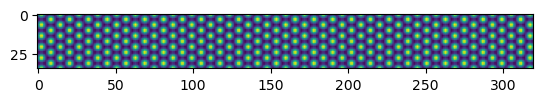

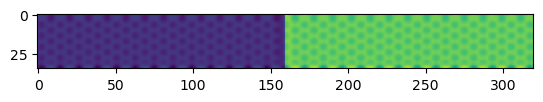

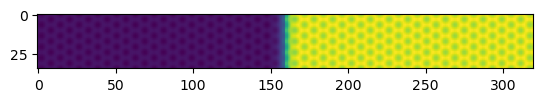

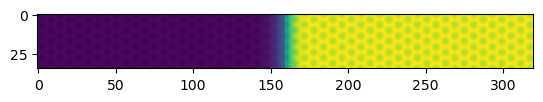

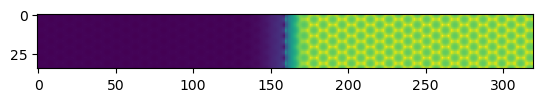

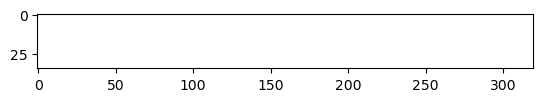

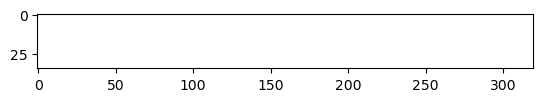

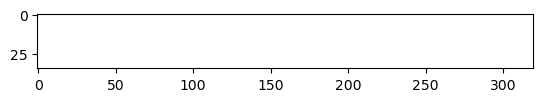

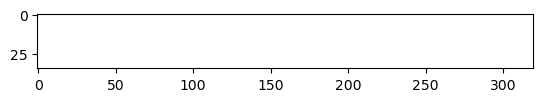

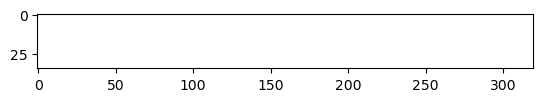

In [40]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
def lapCalc(phi, dx):
    lap = ndimage.laplace(phi)/(dx**2)
    return(lap)
def lmdnCalc(B0l, B2l, B0x, dx, psi, n):
    lapn = lapCalc(n, dx)
    lap2n = lapCalc(lapn, dx)
    ter1 = (B0l-B0x)*n
    ter2 = B2l*psi**2
    ter3 = B0x*(n+2*lapn+lap2n)
    lmdn = ter1 + ter2 + ter3
    return(lmdn)
def dynnCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n):
    lmdn = lmdnCalc(B0l, B2l, B0x, dx, psi, n)
    lappsi = lapCalc(psi, dx)
    ter1 = (MA+MB)*lapCalc(lmdn-t*n**2+v*n**3, dx)
    ter2 = (MA-MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
    dynn = ter1 + ter2
    return(dynn)
def dynpsiCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n):
    lmdn = lmdnCalc(B0l, B2l, B0x, dx, psi, n)
    lappsi = lapCalc(psi, dx)
    ter1 = (MA-MB)*lapCalc(lmdn-t*n**2+v*n**3, dx)
    ter2 = (MA+MB)*((w+B2l*n**2)*psi + u*psi**3 - K * lappsi)
    dynpsi = ter1 + ter2
    return(dynpsi)
# parameter list
a = 6.927
ay = np.sqrt(3)*a
nbar = -0.1501
B0l = 0.7
B2l = -1.8
B0x = 1.0
t = 0.6
v = 1.0
K = 4.0
w = 1.0
u = 4.0
dt = 0.0005
dx = a/7
Lx = 5*a
Ly = 161*ay
Nx = int(Lx/dx)
Ny = int(Ly/dx)
Ny_div2 = int(Ny/2)
qx = 2*np.pi / a
qy = qx / np.sqrt(3)
C = 0.05
MA = 1.0
MB = 0.1
tstep = 2000
tdump = 200
xlst = np.arange(Nx) * dx
ylst = np.arange(Ny) * dx
[xmat, ymat] = np.meshgrid(xlst, ylst,indexing='ij')
# Initialisation
psi = np.zeros((Nx, Ny))
psi[:,Ny_div2:] = 0.2
psi[:,:Ny_div2] = -0.2
# n = nbar + C*(np.cos(2*qy*ymat)/2 - np.cos(qx*xmat)*np.cos(qy*ymat))
n = nbar + C*np.cos(2*qy*ymat) - 2*C*np.cos(qx*xmat)*np.cos(qy*ymat)
# n = np.random.normal(nbar, 0.01, (Nx, Ny))
for t in range(tstep):
    n += dt * dynnCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n)
    psi += dt * dynpsiCalc(B0l, B2l, B0x, t, v, w, u, K, MA, MB, dx, psi, n)
    if (t%tdump == 0):
        plt.figure()
        plt.imshow(n[:,Ny_div2-160:Ny_div2+160]) # 样品很长，只展示中间320个单位长度的信息